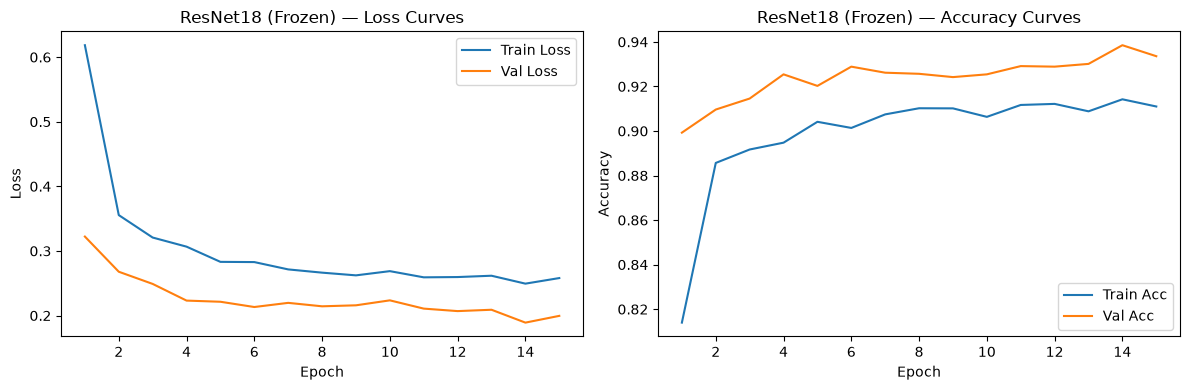

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("../reports/transfer_frozen_training_log.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log["epoch"], log["train_loss"], label="Train Loss")
axes[0].plot(log["epoch"], log["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet18 (Frozen) — Loss Curves")
axes[0].legend()

axes[1].plot(log["epoch"], log["train_acc"], label="Train Acc")
axes[1].plot(log["epoch"], log["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ResNet18 (Frozen) — Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/transfer_frozen_learning_curves.png", dpi=150)
plt.show()

## ResNet18 (Frozen Backbone) — Results Interpretation

### Overall Performance
Frozen-backbone ResNet18 (0.05% of parameters trainable — only the new 
classification head) achieved 93.21% test accuracy, macro F1 0.930, 
weighted F1 0.932 — a modest but real improvement over the baseline CNN 
(92.15% / 0.919 / 0.922), achieved with vastly fewer trainable parameters 
and no architecture designed specifically for this dataset.

### Not a Uniform Win
Transfer learning did not improve every class. Comparing per-class F1 
against the baseline:
- **Improved**: AnnualCrop (+0.03), Forest (+0.03), PermanentCrop (+0.03), 
  Pasture (+0.02), SeaLake (+0.02)
- **Worsened**: Highway (-0.03), River (-0.01), Residential (-0.01)
- **Unchanged**: Industrial

### Highway/River Confusion Got Worse, and Changed Direction
Baseline confused Highway→River (30) more than River→Highway (14), total 
44. Transfer learning shows River→Highway (33) now exceeds Highway→River 
(23), total 56 — a net increase in confusion between this pair, with the 
dominant error direction reversed. This is consistent with the hypothesis 
that ImageNet-pretrained features, learned on natural photographs, are 
not strongly tuned to distinguish thin linear structures (roads vs. 
waterways) at 64x64-scaled-to-224 resolution — this is a plausible 
explanation, not a proven mechanism, and would need further investigation 
(e.g. Grad-CAM in Phase 12) to confirm what the model is actually keying 
on for these two classes.

### PermanentCrop Partially Resolved
Baseline's weakest class (PermanentCrop, recall 0.81) improved substantially 
(recall 0.92). The specific PermanentCrop -> AnnualCrop confusion (31 cases 
in baseline) disappeared entirely. However, confusion with HerbaceousVege-
tation did not disappear — it partly reversed direction, with Herbaceous-
Vegetation -> PermanentCrop (29) now exceeding the reverse (13, down from 
baseline's 30). Net effect: PermanentCrop itself is classified more 
reliably, at some cost to HerbaceousVegetation's precision.

### Conclusion
Transfer learning delivers a real net improvement (+1.06pp accuracy, 
+0.0103 macro F1) with far less trainable capacity, and specifically fixes 
the baseline's clearest weak point (PermanentCrop recall). But it is not 
a strictly-better model class-by-class — it trades some baseline strengths 
(Highway, River) for gains elsewhere. This is a realistic, not idealized, 
transfer-learning outcome, and motivates Phase 9's controlled experiments 
(e.g. fine-tuning the backbone, rather than only training a frozen head, 
may help the model learn features better suited to linear/structural 
distinctions like Highway vs. River).